In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import os
import pickle
import random

import paths

print("Packages loaded")

Packages loaded


In [2]:
n=1
stage = 5
compression=0.05

image = cv2.imread(f'data/n{n}_hh{stage}_shortest_paths.png')
image = cv2.resize(image, None, fx=compression,fy=compression)
nodes = paths.initialise_nodes(image)
print("Node initialisation complete")
adj = paths.initialise_edges(nodes)


Node initialisation complete


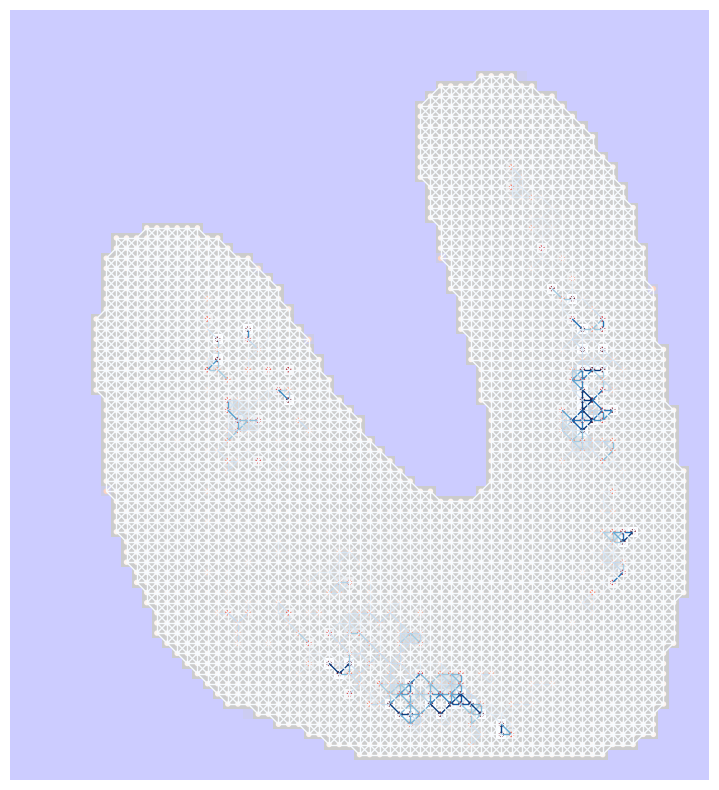

In [3]:
from visualisation import visualise_network
visualise_network(nodes,adj,image,im_alpha=0.2,node_size=0.2,edge_width=1)

Network generation finished
550 2331
258 1044
482 2029
1841 1934
1554 859
384 1998
116 1596
1772 2488
8 1824
1090 937
2421 418
1300 125
91 104
2217 37
1561 887
1728 118
2161 908
1793 2030
2264 954
1415 945


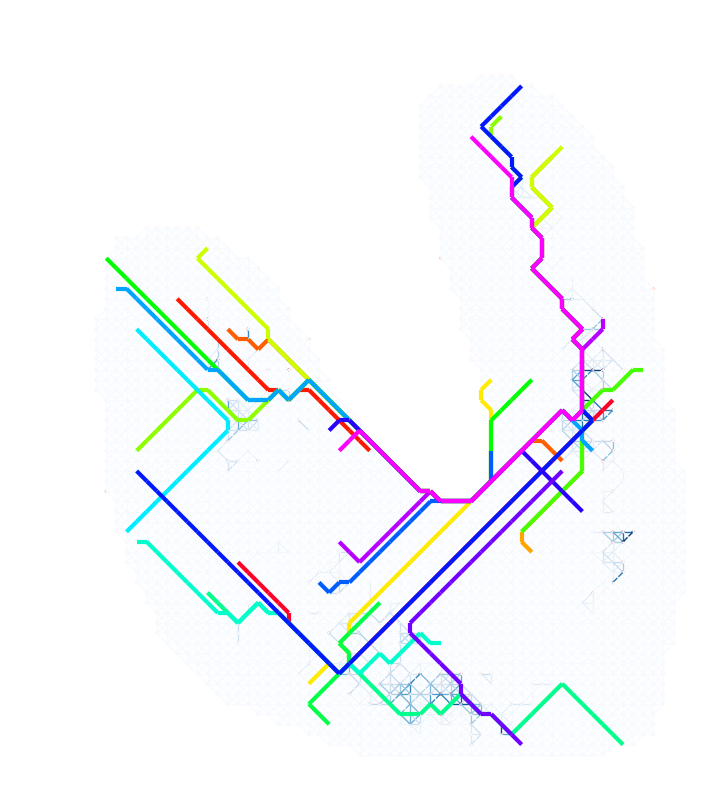

0
0.0
1
0.0
2
0.0
3
0.0
4
0.0
5
0.0
6
0.0
7
0.0
8
0.0012953367875647669
9
0.0
10
0.0
11
0.0
12
0.0
13
0.0
14
0.0
15
0.0
16
0.0
17
0.0
18
0.0
19
0.0
20
0.0
21
0.0
22
0.0
23
0.0
24
0.0
25
0.0
26
0.0
27
0.0
28
0.0
29
0.0
30
0.0
31
0.0
32
0.0
33
0.0
34
0.0
35
0.0012953367875647669
36
0.0
37
0.0012953367875647669
38
0.0
39
0.0
40
0.0
41
0.0
42
0.0
43
0.0
44
0.0
45
0.0
46
0.0
47
0.0
48
0.0
49
0.0
50
0.0
51
0.0
52
0.0
53
0.0
54
0.0
55
0.0
56
0.0
57
0.0
58
0.0
59
0.0
60
0.0
61
0.0
62
0.0
63
0.0
64
0.0
65
0.0
66
0.0012953367875647669
67
0.0012953367875647669
68
0.0
69
0.0
70
0.0
71
0.0
72
0.0
73
0.0
74
0.0
75
0.0
76
0.0
77
0.0
78
0.0
79
0.0
80
0.0
81
0.0
82
0.0
83
0.0
84
0.0
85
0.0
86
0.0
87
0.0
88
0.0
89
0.0
90
0.0
91
0.0012953367875647669
92
0.0
93
0.0
94
0.0
95
0.0
96
0.0
97
0.0
98
0.0
99
0.0
100
0.0012953367875647669
101
0.0012953367875647669
102
0.0
103
0.0
104
0.0012953367875647669
105
0.0
106
0.0
107
0.0
108
0.0
109
0.0
110
0.0
111
0.0
112
0.0
113
0.0
114
0.0
115
0.0
116
0.00129533678756

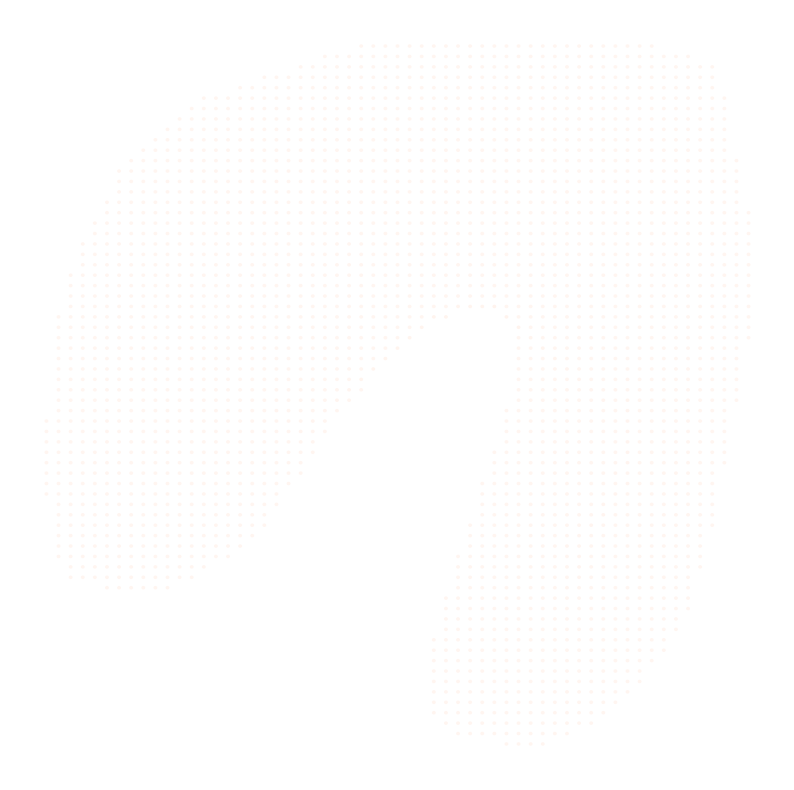

In [ ]:
paths.stochastic_paths(nodes,adj,100,image=image, display_paths=True, display_treads=True,start_type="blood island")

In [ ]:
#old code below
def process_new_treads(net,path_tread,particles):
    path_tread = path_tread/max(path_tread)
    
    for i in path_tread.index:
        if path_tread.loc[i]>0:
            nx.set_node_attributes(net,{i:path_tread.loc[i]*25+5},name="size")
        else: 
            nx.set_node_attributes(net,{i:0},name="size")

        if path_tread.loc[i]>0 and i not in particles:
            nx.set_node_attributes(net,{i:3},name="group")
    nx.set_node_attributes(net,"",name="label")
    return net

In [ ]:
def update_difficulty(net,param,particles):
    node1 = list(nx.get_edge_attributes(net,"width"))[0][0]
    node2 = list(nx.get_edge_attributes(net,"width"))[0][1]
    width =  nx.get_edge_attributes(net,"width")[(node1,node2)]
    if not (node1 in particles and node2 in particles): #only edges where difficulty param applies
        x1,y1 = node1.split(",")
        x2,y2 = node2.split(",")
        dist = np.sqrt((float(x1)-float(x2))**2+(float(y1)-float(y2))**2)
        sf = param*dist/width
    print(sf)
    for i in list(net.edges):
      if not (i[0] in particles and i[1] in particles):
        nx.set_edge_attributes(net,sf*nx.get_edge_attributes(net,"width")[i],"width")

    return net

In [ ]:
stage=5
compression=1
n=1
difficulty_param = 20
path=f"results/shortest_paths/hh{stage}/"
name=f"n{n}_hh{stage}_compression{compression}"

try:
    net = pickle.load(open(f"{path}{name}_network.txt","rb"))
    particles = pickle.load(open(f"{path}{name}_particles.txt","rb"))

    print("Success opening file...")
except:
    print("Save file not found - generating graph...")
    image = cv2.imread(f'data/particles_hh{stage}_red_test.jpg')
    image = cv2.resize(image, None, fx=compression,fy=compression)
    cv2.imwrite(f'data/particles_hh{stage}_{compression}_compressed.jpg',image)

    try:
        open(f"{path}{name}_network.txt","x") #creates the file to write to
        open(f"{path}{name}_particles.txt","x") 
    except:
        raise Exception(f"The file {path}{name}_network.txt already exists but could not be read successfully - please delete or move to avoid overwriting data.")
    

    #form network
    net,particles=path_weight_network(image,parameter=difficulty_param)
    display_network(net,f"{path}{name}_network.html")

    

    if not os.path.exists(path):
        os.makedirs(path)
        
    #save network info
    
    pickle.dump(net,open(f"{path}{name}_network.txt","wb"))
    pickle.dump(particles,open(f"{path}{name}_particles.txt","wb"))

finally:
    #net=update_difficulty(net,difficulty_param)
    print(f"File generation complete: {net}")
    net2,path_tread = stochastic_paths(1000,net,particles)

    pickle.dump(net2,open(f"{path}{name}_network_paths.txt","wb"))
    #display_network(net2,f"{path}{name}_network_paths.html")

    print("Processing treads")
    net3 = process_new_treads(net,path_tread,particles)
    pickle.dump(net3,open(f"{path}{name}_network_treads.txt","wb"))
    print("Writing")
    display_network(net3,f"{path}{name}_network_treads.html")
    



Success opening file...
File generation complete: Graph with 26211 nodes and 103375 edges
Local cdn resources have problems on chrome/safari when used in jupyter-notebook. 
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\isabe\.local\share\mamba\envs\networks\Lib\site-packages\IPython\core\interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\isabe\AppData\Local\Temp\ipykernel_18096\69796369.py", line 45, in <module>
    display_network(net2,f"{path}{name}_network_paths.html")
  File "C:\Users\isabe\AppData\Local\Temp\ipykernel_18096\3569696471.py", line 4, in display_network
    new_net.from_nx(net)
  File "C:\Users\isabe\.local\share\mamba\envs\networks\Lib\site-packages\pyvis\network.py", line 717, in from_nx
    self.add_edge(e[0], e[1], **e[2])
  File "C:\Users\isabe\.local\share\mamba\envs\networks\Lib\site-packages\pyvis\network.py", line None, in add_edge
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\isabe\.local\share\mamba\envs\networks\Lib\site-packages\IPython\core\interactiveshell.py",

In [ ]:
net3 = pickle.load(open(f"{path}{name}_network_treads.txt","rb"))
display_network(net3,f"{path}{name}_network_treads.html")

Local cdn resources have problems on chrome/safari when used in jupyter-notebook. 
